In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def compute_loss(y_true, y_pred):
    m = len(y_true)
    return - (1/m) * np.sum(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15))

def train_logistic(X, y, lr=0.1, epochs=1000):
    m, n = X.shape
    weights = np.zeros(n)
    bias = 0
    losses = []

    for epoch in range(epochs):
        z = np.dot(X, weights) + bias
        y_pred = sigmoid(z)

        loss = compute_loss(y, y_pred)
        losses.append(loss)

        dw = (1/m) * np.dot(X.T, (y_pred - y))
        db = (1/m) * np.sum(y_pred - y)

        weights -= lr * dw
        bias -= lr * db

    return weights, bias, losses

def predict(X, weights, bias, threshold=0.5):
    probs = sigmoid(np.dot(X, weights) + bias)
    return (probs >= threshold).astype(int)

# Binary target: 1 if tip_pct > 15%, else 0
df['tip_pct'] = df['tip'] / df['total_bill']
df['tip_class'] = (df['tip_pct'] > 0.15).astype(int)

# Use two features: total_bill and size
X = df[['total_bill', 'size']].values
y = df['tip_class'].values

X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

weights, bias, losses = train_logistic(X, y)


In [7]:
from sklearn.metrics import accuracy_score

y_pred = predict(X, weights, bias)
print("Accuracy:", accuracy_score(y, y_pred))


Accuracy: 0.6475409836065574


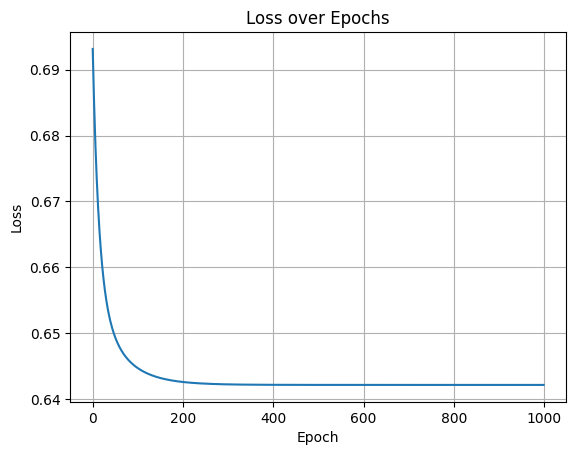

In [8]:
plt.plot(losses)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()
